In [2]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt

In [3]:
from google.cloud import bigquery

client = bigquery.Client()

query = """
SELECT *
FROM `bigquery-public-data.chicago_taxi_trips.taxi_trips`
LIMIT 100000
"""

data = client.query(query).to_dataframe()

data.to_csv("/kaggle/working/chicago_taxi_trips.csv", index=False)

Using Kaggle's public dataset BigQuery integration.


/usr/local/lib/python3.12/dist-packages/google/cloud/bigquery/table.py:2086: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


In [9]:
data.head()

,unique_key,taxi_id,trip_start_timestamp,trip_end_timestamp,trip_seconds,trip_miles,pickup_census_tract,dropoff_census_tract,pickup_community_area,dropoff_community_area,...,extras,trip_total,payment_type,company,pickup_latitude,pickup_longitude,pickup_location,dropoff_latitude,dropoff_longitude,dropoff_location
0,548a466eb60e2ba0a9d3e8090a52d2a47a9e61b3,be7e1462a37397809dadade8e174ef3ccbc3073294df4a...,2013-06-25 19:00:00+00:00,2013-06-25 19:00:00+00:00,<NA>,0.0,<NA>,<NA>,<NA>,<NA>,...,0.0,9.17,Credit Card,Chicago Elite Cab Corp.,NaN,NaN,None,NaN,NaN,None
1,3da9d221231073a3086f1cda8c735c6488810e52,2df889887daaafd8ca9517b2c47ae1a0e3ba41e4da63fb...,2013-07-06 14:15:00+00:00,2013-07-06 14:15:00+00:00,<NA>,0.0,<NA>,<NA>,<NA>,<NA>,...,0.0,10.62,Credit Card,Chicago Elite Cab Corp.,NaN,NaN,None,NaN,NaN,None
2,38bdd7a9b666a2fa02da2a8581627bcec7858f60,05001a5e70a7a8f38a2e4d2ee8a1e0fb87a20857413b44...,2013-06-26 10:45:00+00:00,2013-06-26 10:45:00+00:00,0,0.0,<NA>,<NA>,<NA>,<NA>,...,0.0,9.42,Credit Card,Chicago Elite Cab Corp.,NaN,NaN,None,NaN,NaN,None
3,fb827cae8de967442074fc9fda14bb8cc103e8a1,e3ac7ea12583fa93441f6fe24c09f75baa4a4b52d2e06c...,2013-06-25 20:15:00+00:00,2013-06-25 20:15:00+00:00,<NA>,0.0,<NA>,<NA>,<NA>,<NA>,...,0.0,17.82,Credit Card,Chicago Elite Cab Corp.,NaN,NaN,None,NaN,NaN,None
4,50ebb67a98ae62f9a6f0635290d08888b97f8217,54439f9e86489e7fe7392849f7c77a84376c4a61c1458f...,2013-06-25 01:45:00+00:00,2013-06-25 01:45:00+00:00,0,0.0,<NA>,<NA>,<NA>,<NA>,...,0.0,10.86,Credit Card,Chicago Elite Cab Corp.,NaN,NaN,None,NaN,NaN,None


In [11]:
data.shape

(100000, 23)

In [12]:
data.columns

Index(['unique_key', 'taxi_id', 'trip_start_timestamp', 'trip_end_timestamp',
       'trip_seconds', 'trip_miles', 'pickup_census_tract',
       'dropoff_census_tract', 'pickup_community_area',
       'dropoff_community_area', 'fare', 'tips', 'tolls', 'extras',
       'trip_total', 'payment_type', 'company', 'pickup_latitude',
       'pickup_longitude', 'pickup_location', 'dropoff_latitude',
       'dropoff_longitude', 'dropoff_location'],
      dtype='object')

In [13]:
# Dropping columns which are not needed
drop_cols = [
    "unique_key",
    "taxi_id",
    "trip_end_timestamp",
    "pickup_census_tract",
    "dropoff_census_tract",
    "tips",
    "tolls",
    "extras",
    "trip_total",
    "pickup_location",
    "dropoff_location"
]

data = data.drop(columns=drop_cols)

In [14]:
# Again inspecting data after cleaning
data.head()

,trip_start_timestamp,trip_seconds,trip_miles,pickup_community_area,dropoff_community_area,fare,payment_type,company,pickup_latitude,pickup_longitude,dropoff_latitude,dropoff_longitude
0,2013-06-25 19:00:00+00:00,<NA>,0.0,<NA>,<NA>,7.05,Credit Card,Chicago Elite Cab Corp.,NaN,NaN,NaN,NaN
1,2013-07-06 14:15:00+00:00,<NA>,0.0,<NA>,<NA>,8.85,Credit Card,Chicago Elite Cab Corp.,NaN,NaN,NaN,NaN
2,2013-06-26 10:45:00+00:00,0,0.0,<NA>,<NA>,7.85,Credit Card,Chicago Elite Cab Corp.,NaN,NaN,NaN,NaN
3,2013-06-25 20:15:00+00:00,<NA>,0.0,<NA>,<NA>,14.85,Credit Card,Chicago Elite Cab Corp.,NaN,NaN,NaN,NaN
4,2013-06-25 01:45:00+00:00,0,0.0,<NA>,<NA>,9.05,Credit Card,Chicago Elite Cab Corp.,NaN,NaN,NaN,NaN


In [15]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 12 columns):
 #   Column                  Non-Null Count   Dtype              
---  ------                  --------------   -----              
 0   trip_start_timestamp    100000 non-null  datetime64[us, UTC]
 1   trip_seconds            98091 non-null   Int64              
 2   trip_miles              100000 non-null  float64            
 3   pickup_community_area   81250 non-null   Int64              
 4   dropoff_community_area  60284 non-null   Int64              
 5   fare                    100000 non-null  float64            
 6   payment_type            100000 non-null  object             
 7   company                 99644 non-null   object             
 8   pickup_latitude         81252 non-null   float64            
 9   pickup_longitude        81252 non-null   float64            
 10  dropoff_latitude        60284 non-null   float64            
 11  dropoff_longitude       602

In [17]:
data.isnull().sum().sort_values(ascending=False)

dropoff_longitude         39716
dropoff_latitude          39716
dropoff_community_area    39716
pickup_community_area     18750
pickup_latitude           18748
pickup_longitude          18748
trip_seconds               1909
company                     356
trip_miles                    0
trip_start_timestamp          0
payment_type                  0
fare                          0
dtype: int64

In [18]:
data.describe(include="all")

,trip_start_timestamp,trip_seconds,trip_miles,pickup_community_area,dropoff_community_area,fare,payment_type,company,pickup_latitude,pickup_longitude,dropoff_latitude,dropoff_longitude
count,100000,98091.0,100000.000000,81250.0,60284.0,100000.000000,100000,99644,81252.000000,81252.000000,60284.000000,60284.000000
unique,NaN,<NA>,NaN,<NA>,<NA>,NaN,8,32,NaN,NaN,NaN,NaN
top,NaN,<NA>,NaN,<NA>,<NA>,NaN,Cash,Yellow Cab,NaN,NaN,NaN,NaN
freq,NaN,<NA>,NaN,<NA>,<NA>,NaN,53581,81129,NaN,NaN,NaN,NaN
mean,2015-08-10 02:29:17.034000+00:00,1174.94498,7.991125,36.069218,44.070798,19.973197,NaN,NaN,41.883238,-87.687937,41.815861,-87.661703
min,2013-06-18 21:00:00+00:00,0.0,0.000000,1.0,29.0,0.000000,NaN,NaN,41.660136,-87.913625,41.660136,-87.791503
25%,2015-04-10 21:00:00+00:00,531.0,1.700000,21.0,33.0,8.450000,NaN,NaN,41.850266,-87.723583,41.785999,-87.750934
50%,2015-05-16 10:15:00+00:00,999.0,5.900000,32.0,41.0,16.250000,NaN,NaN,41.880994,-87.633308,41.812949,-87.624135
75%,2015-06-17 15:03:45+00:00,1594.5,12.700000,56.0,56.0,28.250000,NaN,NaN,41.901207,-87.622173,41.849247,-87.617358
max,2018-06-03 00:00:00+00:00,78096.0,245.400000,77.0,75.0,983.650000,NaN,NaN,42.016046,-87.534903,41.859350,-87.534903


In [20]:
cols_to_drop = [
    "pickup_latitude",
    "pickup_longitude",
    "dropoff_latitude",
    "dropoff_longitude"
]

data = data.drop(columns=cols_to_drop)

In [22]:
data['trip_seconds'] = data['trip_seconds'].fillna(data['trip_seconds'].median())

In [ ]:
data["company"] = data["company"].fillna(data["company"].mode()[0])

In [25]:
data["pickup_community_area"] = data["pickup_community_area"].fillna(
    data["pickup_community_area"].mode()[0]
)

data["dropoff_community_area"] = data["dropoff_community_area"].fillna(
    data["dropoff_community_area"].mode()[0]
)

In [27]:
data.describe()

,trip_seconds,trip_miles,pickup_community_area,dropoff_community_area,fare
count,100000.0,100000.000000,100000.0,100000.0,100000.000000
mean,1171.58619,7.991125,35.30624,48.8086,19.973197
std,1133.035049,8.034797,20.663595,10.722509,15.711103
min,0.0,0.000000,1.0,29.0,0.000000
25%,540.0,1.700000,28.0,36.0,8.450000
50%,999.0,5.900000,32.0,56.0,16.250000
75%,1578.0,12.700000,41.0,56.0,28.250000
max,78096.0,245.400000,77.0,75.0,983.650000


In [28]:
# More cleaning
data = data[data["fare"] > 0]
data = data[data["trip_miles"] > 0]
data = data[data["trip_seconds"] > 0]

In [30]:
# applying interquartile range

Q1 = data["fare"].quantile(0.25)
Q3 = data["fare"].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - IQR * 1.5
upper = Q3 + 1.5 * IQR

data = data[(data["fare"] >= lower) & (data["fare"] <= upper)]

In [31]:
# Feature Engineering

data["hour"] = data["trip_start_timestamp"].dt.hour
data["day"] = data["trip_start_timestamp"].dt.day
data["month"] = data["trip_start_timestamp"].dt.month
data["weekday"] = data["trip_start_timestamp"].dt.dayofweek

In [32]:
# Droping original timestamp
data = data.drop(columns=["trip_start_timestamp"])

In [35]:
# using one-hot encoding to handle categorical values
data = pd.get_dummies(data,columns=["payment_type","company"],drop_first=True)

In [36]:
# separating, features and target
x = data.drop("fare",axis=1)
y = data["fare"]

In [37]:
# splitting the data
from  sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test = train_test_split(
    x,y,test_size=0.2,random_state=42
)

In [38]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train,y_train)

LinearRegression()

In [39]:
y_pred = model.predict(X_test)

In [40]:
from sklearn.metrics import mean_absolute_error

mae = mean_absolute_error(y_test,y_pred)
print("MAE: ",mae)

MAE:  1.2096748777539181


In [41]:
from sklearn.metrics import root_mean_squared_error

rmse = root_mean_squared_error(y_test,y_pred)
print("RMSE: ",rmse)

RMSE:  3.253654560476931


In [43]:
from sklearn.metrics import r2_score
r2 = r2_score(y_test,y_pred)
print("R2 score: ",r2)

R2 score:  0.9291077012069999


# Plotting against training data

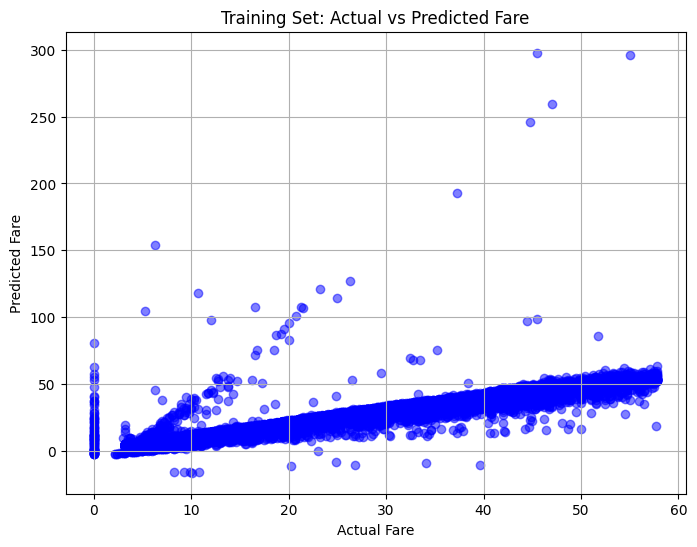

In [47]:
import matplotlib.pyplot as plt

y_train_pred = model.predict(X_train)

plt.figure(figsize=(8,6))
plt.scatter(y_train,y_train_pred,color="blue",alpha=0.5)

plt.title("Training Set: Actual vs Predicted Fare")
plt.xlabel("Actual Fare")
plt.ylabel("Predicted Fare")
plt.grid(True)
plt.show()

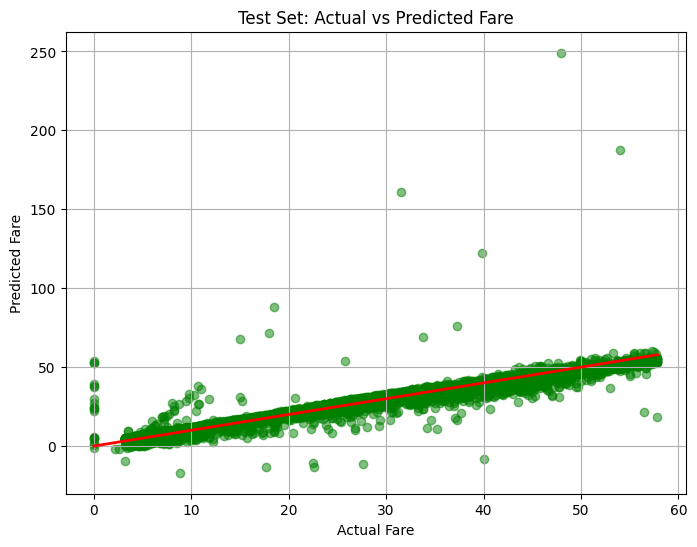

In [48]:
# Predictions on test data
y_test_pred = model.predict(X_test)

plt.figure(figsize=(8,6))
plt.scatter(y_test, y_test_pred, color='green', alpha=0.5)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         color='red', linewidth=2)

plt.title("Test Set: Actual vs Predicted Fare")
plt.xlabel("Actual Fare")
plt.ylabel("Predicted Fare")
plt.grid(True)
plt.show()

## Residual Plot

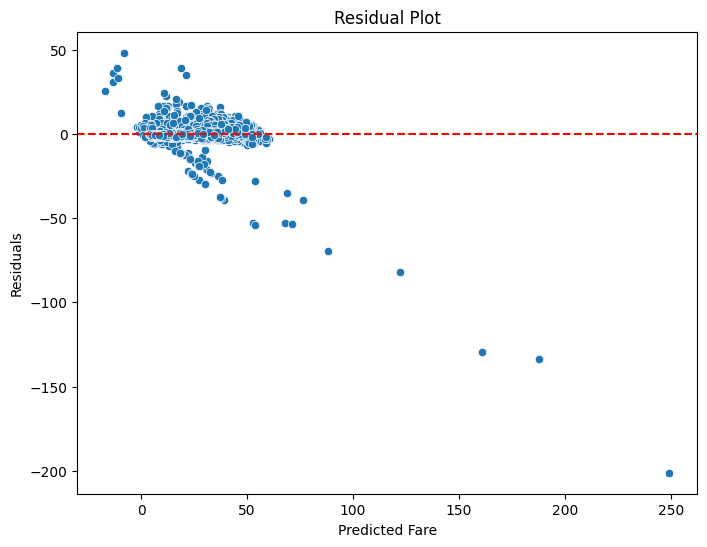

In [49]:
import seaborn as sns

residuals = y_test - y_test_pred

plt.figure(figsize=(8,6))
sns.scatterplot(x=y_test_pred, y=residuals)

plt.axhline(y=0, color='red', linestyle='--')
plt.title("Residual Plot")
plt.xlabel("Predicted Fare")
plt.ylabel("Residuals")
plt.show()

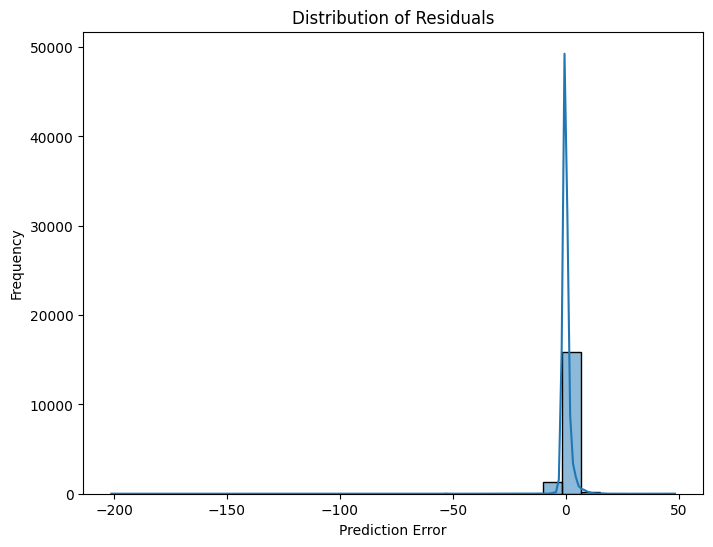

In [50]:
plt.figure(figsize=(8,6))
sns.histplot(residuals, bins=30, kde=True)

plt.title("Distribution of Residuals")
plt.xlabel("Prediction Error")
plt.ylabel("Frequency")
plt.show()